# Layers and Shared Type-Wells

In [1]:
import os
import glob
import numpy as np
np.random.seed(1234567)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Automatically detect if running on Kaggle or Locally
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")

Running on Local Environment
Data Directory: ../data


In [3]:
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))
file_paths[:10]

['.DS_Store',
 '000d7d20.png',
 '000d7d20__horizontal_well.csv',
 '000d7d20__typewell.csv',
 '00bbac68.png',
 '00bbac68__horizontal_well.csv',
 '00bbac68__typewell.csv',
 '00e12e8b.png',
 '00e12e8b__horizontal_well.csv',
 '00e12e8b__typewell.csv']

In [4]:
# Regex pattern: 
pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")
print("Every Well Name has 3 files: ")
print(len(file_paths) / 3 == len(well_names))

Extracted Well Names:
773 Well Names
Every Well Name has 3 files: 
False


In [5]:
sample_well = np.random.choice(well_names)

horizontal_well_csv = pd.read_csv(train_data + f"/{sample_well}__horizontal_well.csv")
typewell_csv = pd.read_csv(train_data + f"/{sample_well}__typewell.csv")
pic = train_data + f"/{sample_well}.png"

sample_well, horizontal_well_csv.shape, typewell_csv.shape

(np.str_('8b95d6d1'), (2783, 13), (1245, 3))

$$TVT = \text{Typewell\_Base\_Depth}_{\text{Layer}} + (\text{Layer} - Z)$$

$$TVT = K + (ANCC - Z)$$

This K remains same throughout a well.

0.00762463665042099

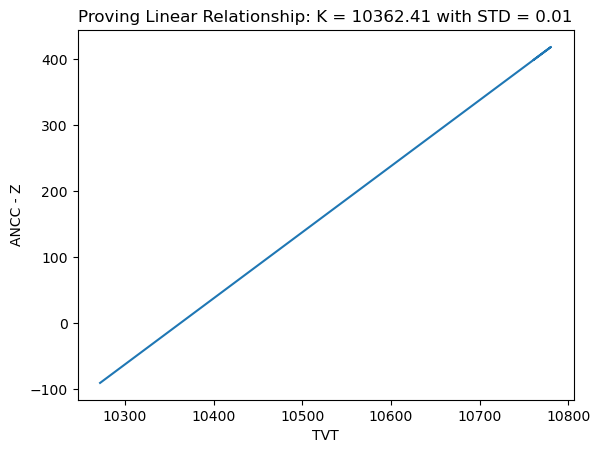

In [6]:
K = horizontal_well_csv['TVT'] - (horizontal_well_csv['ANCC'] - horizontal_well_csv['Z'])
mean = np.mean(K); std = np.std(K)

plt.title(f"Proving Linear Relationship: K = {mean:.2f} with STD = {std:.2f}")
plt.xlabel('TVT')
plt.ylabel('ANCC - Z')
plt.plot(horizontal_well_csv['TVT'], (horizontal_well_csv['ANCC'] - horizontal_well_csv['Z']))
np.std(horizontal_well_csv['TVT'] - (horizontal_well_csv['ANCC'] - horizontal_well_csv['Z']))

$$ Layer_1 = Constant + Layer_2 $$
Again, this Constant like the earlier one remains same for the data of a single well.

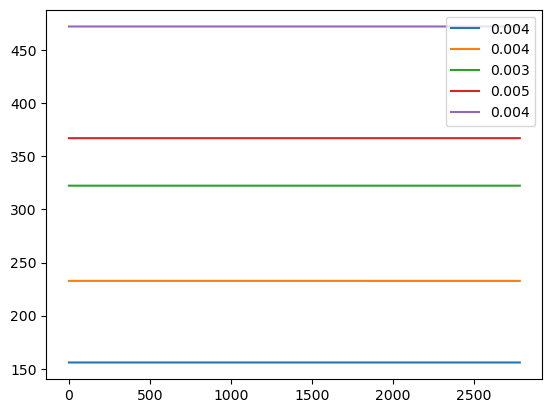

In [7]:
diffs = [(horizontal_well_csv['ANCC'] - horizontal_well_csv['ASTNU']),
(horizontal_well_csv['ANCC'] - horizontal_well_csv['ASTNL']),
(horizontal_well_csv['ANCC'] - horizontal_well_csv['EGFDU']),
(horizontal_well_csv['ANCC'] - horizontal_well_csv['EGFDL']),
# (horizontal_well_csv['TVT'] + horizontal_well_csv['Z'] - horizontal_well_csv['ASTNL']),
(horizontal_well_csv['ANCC'] - horizontal_well_csv['BUDA'])
        ]
for diff in diffs:
    plt.plot(diff, label=round(np.std(diff), 3))
plt.legend()

Eqns:
$$ Layer_1 = Constant + Layer_2 $$
$$TVT = K + (ASTNU - Z)$$

All of the constants from these equations can be reduced to:
* $K_1 = TVT - (ANCC - Z)$
* $K_2 = ANCC - ASTNU$
* $K_3 = ANCC - ASTNL$
* $K_4 = ANCC - EGFDU$
* $K_5 = ANCC - EGFDL$
* $K_5 = ANCC - BUDA$

Proving that these constants aresn't same for different wells:

In [8]:
constants_data = []
for well in well_names:
    well_csv = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
    
    # K1 = TVT - (ANCC - Z)
    k1 = (well_csv['TVT'] - (well_csv['ASTNL'] - well_csv['Z'])).mean()
    # Geological Offsets
    # ASTNL is found in all the trianing data
    k3 = (well_csv['ASTNL'] - well_csv['ANCC']).mean()
    k2 = (well_csv['ASTNL'] - well_csv['ASTNU']).mean()
    k4 = (well_csv['ASTNL'] - well_csv['EGFDU']).mean()
    k5 = (well_csv['ASTNL'] - well_csv['EGFDL']).mean()
    k6 = (well_csv['ASTNL'] - well_csv['BUDA']).mean()
    
    constants_data.append({
        'WELLNAME': well,
        'K1': round(k1, 2),
        'K2': round(k2, 2),
        'K3': round(k3, 2),
        'K4': round(k4, 2),
        'K5': round(k5, 2),
        'K6': round(k6, 2)
    })

constants_df = pd.DataFrame(constants_data)
display(constants_df.head())

,WELLNAME,K1,K2,K3,K4,K5,K6
0,000d7d20,11575.09,-27.78,-201.83,73.35,108.32,248.71
1,00bbac68,12031.97,-32.09,-176.77,115.77,152.15,289.75
2,00e12e8b,11575.09,-27.78,-201.83,73.35,108.32,248.71
3,015fe0d2,12031.97,-32.09,-176.77,115.77,152.15,289.75
4,01869cd4,11575.09,-27.78,-201.83,73.35,108.32,248.71


In [9]:
#constants_df.to_csv('../data/ks.csv', index=False)
constants_df[constants_df.isna().any(axis=1)]

,WELLNAME,K1,K2,K3,K4,K5,K6
9,03a935ae,12638.29,-55.86,NaN,31.38,80.96,248.78
78,1b1eba53,12638.29,-55.86,NaN,31.38,80.96,248.78
225,4c2208f5,12638.29,-55.86,NaN,31.38,80.96,248.78
331,727a3a10,12638.29,-55.86,NaN,31.38,80.96,248.78
369,81bf5923,12638.29,-55.86,NaN,31.38,80.96,248.78
469,9dfff011,11210.31,-88.95,-234.0,122.70,NaN,284.11
505,a8ed028a,12638.29,-55.86,NaN,31.38,80.96,248.78
644,d7eb0be8,12638.29,-55.86,NaN,31.38,80.96,248.78


Noticing that there are repetitive sets of K1, K2, K3, K4, K5 & K6:

They probably have classes of wells for which they have the same Ks.

These wells belonging to the same class have more similarities than just that, more of that later.

* For these wells the typewell seems to be matchings like subsequences of a common sequence.
* I had also found that K remains same for a single well.
* The files with all the Ks missing are of a single group with constant difference between the other layers.
* Somehow this k5=nan family is matching another family, just with the k5 = 408.4
* However the rest 7 of all k as nan, don't fall in other families. But they still follow the 2 equations.
* Similar K Values were seen from the same Class
* However no such relationship between the weights.

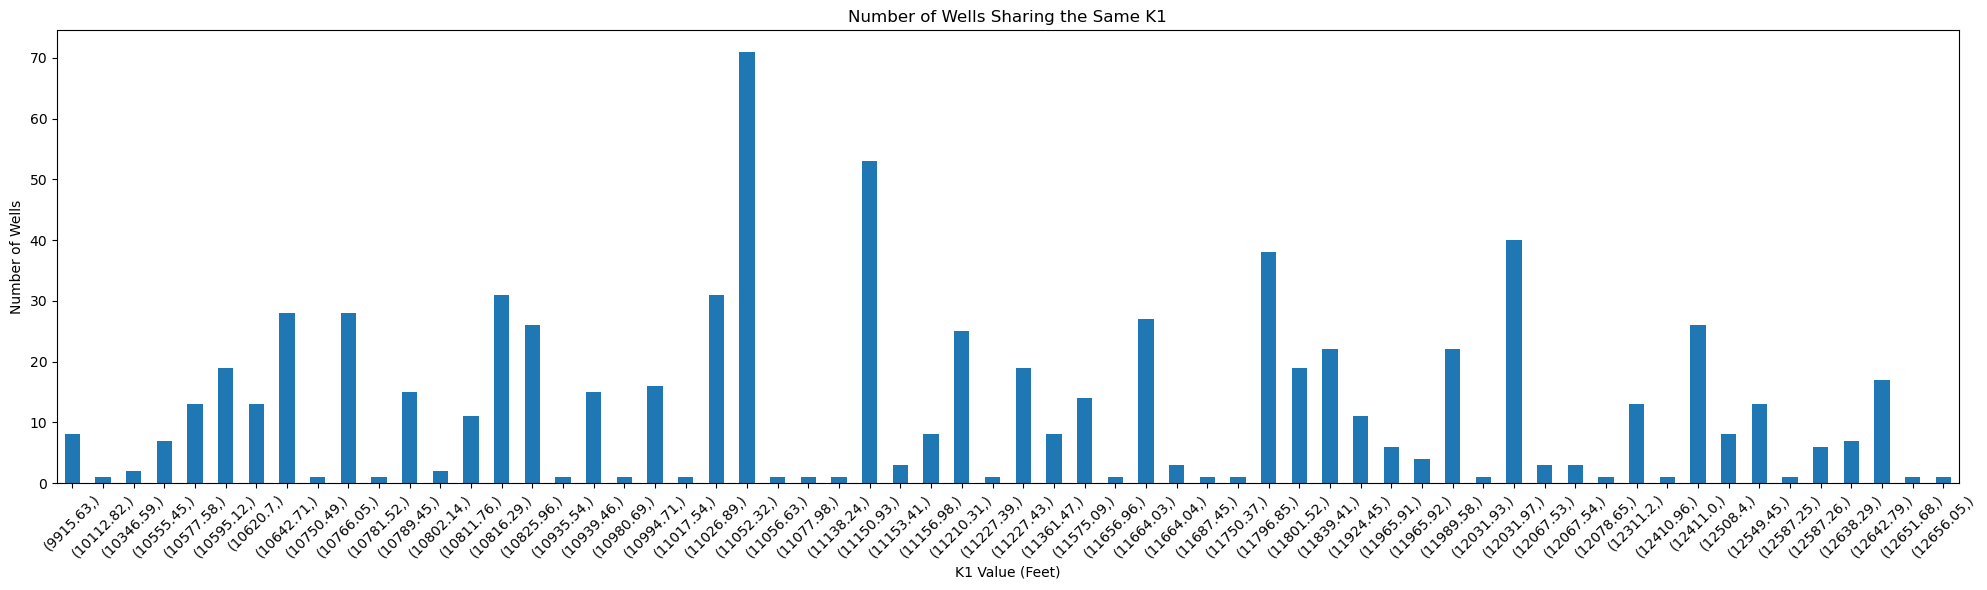

62

In [10]:
# 1. Count how many wells share the exact same K1 value
k1_counts = constants_df[['K1']].value_counts().sort_index()

# 2. Plot the bar graph
plt.figure(figsize=(20, 6))
k1_counts.plot(kind='bar')

# 3. Add labels and title
plt.title('Number of Wells Sharing the Same K1')
plt.xlabel('K1 Value (Feet)')
plt.ylabel('Number of Wells')

# Rotate X-axis labels so they are readable
plt.xticks(rotation=45)

# Adjust layout to fit everything nicely
plt.tight_layout()
plt.show()
len(k1_counts)

## Better way to see the classes

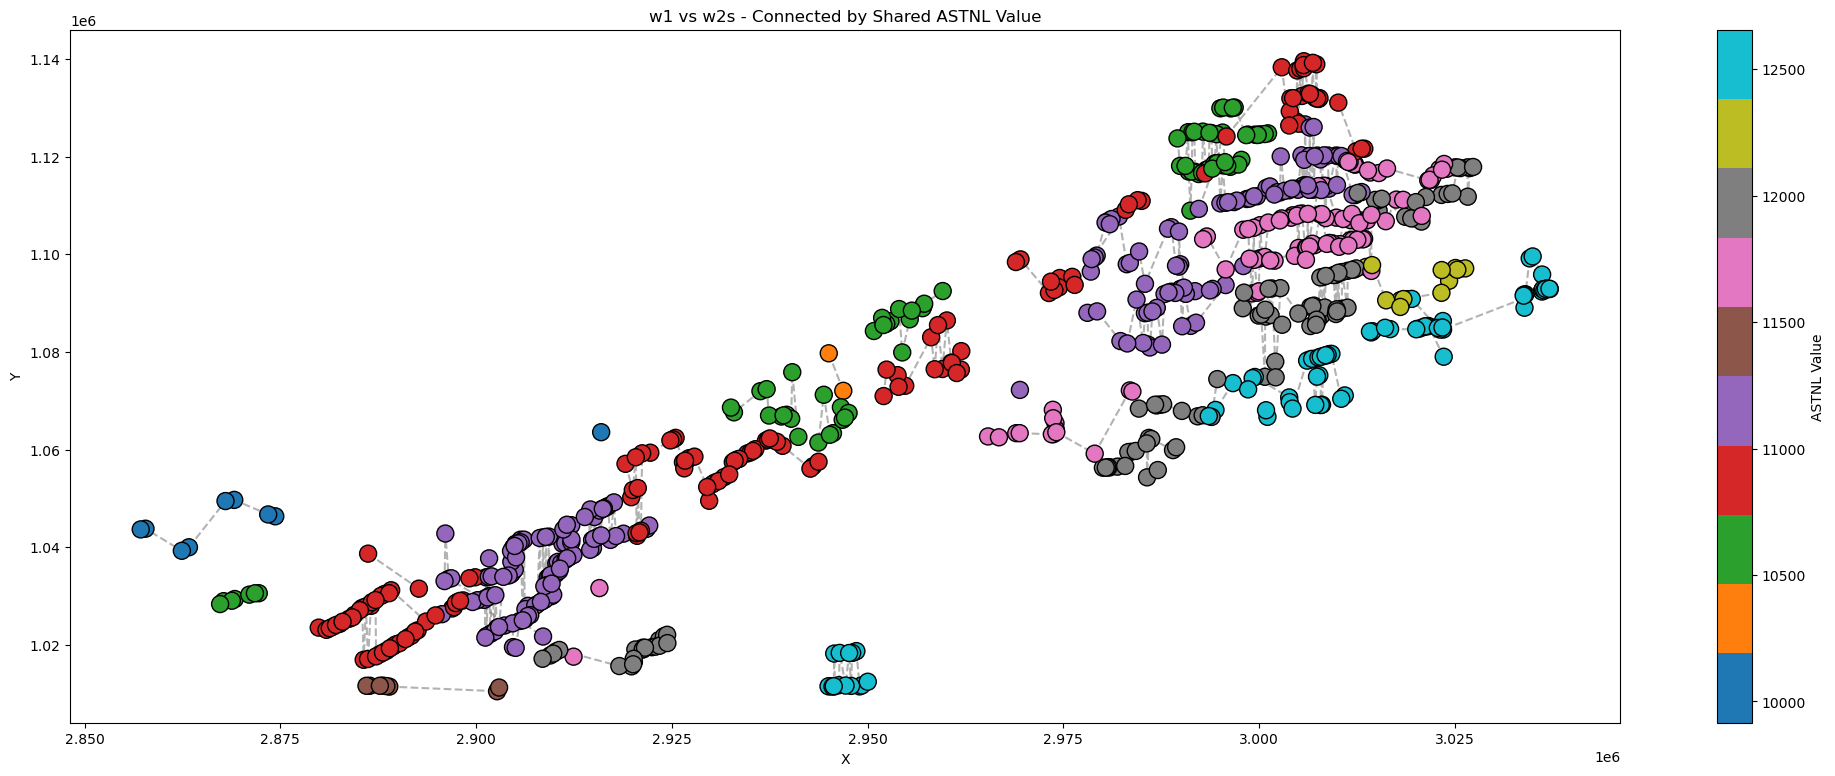

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 9))
points = list()

for w in well_names[:]:
    h = pd.read_csv(f'../data/train/{w}__horizontal_well.csv')
    t = pd.read_csv(f'../data/train/{w}__typewell.csv')
    e = h[h['TVT_input'].isna()]
    astnl = t['TVT'][t['Geology'] == 'ASTNL'].iloc[0] if not t[t['Geology'] == 'ASTNL'].empty else np.nan 
    points.append((e['X'].median(), e['Y'].median(), astnl))

# 1. Convert to a DataFrame to easily group by the 'astnl' column
df = pd.DataFrame(points, columns=['X', 'Y', 'astnl'])

# 2. Drop rows where astnl is NaN, as we can't group them by shared value
df_clean = df.dropna(subset=['astnl'])

# 3. Plot the base scatter points with a colormap and crisp edges
sc = plt.scatter(df_clean['X'], df_clean['Y'], c=df_clean['astnl'], cmap='tab10', s=150, zorder=3, edgecolors='black')

# 4. Group by 'astnl' and draw connecting lines
for astnl_val, group in df_clean.groupby('astnl'):
    if len(group) > 1:
        # Sort by X (or Y) to make the line drawing sequential rather than crisscrossed
        group_sorted = group.sort_values(by='X')
        
        plt.plot(
            group_sorted['X'], 
            group_sorted['Y'], 
            linestyle='--',      # Dashed line looks clean for connections
            linewidth=1.5,       # Subtle line weight
            alpha=0.6,           # Slight transparency so it doesn't overwhelm the points
            color='gray',        # Neutral gray, or match group color if preferred
            zorder=2             # Keeps lines underneath the scatter points
        )

plt.xlabel('X')
plt.ylabel('Y')
plt.title('w1 vs w2s - Connected by Shared ASTNL Value')

# 5. Fixed: Use a colorbar instead of plt.legend() since 'c' is an array of values
cbar = plt.colorbar(sc)
cbar.set_label('ASTNL Value')

plt.show()
